## 🧬 Automated Protein Structure Visualization & Biophysical Analysis Suite

### Overview

This Google Colab notebook provides an automated, end-to-end bioinformatics pipeline designed to parse, analyze, and visualize 3D macromolecular structures directly from the **RCSB Protein Data Bank (PDB)**. By combining structural geometry calculations with interactive WebGL rendering, the tool bridges raw atomic coordinate datasets with publication-quality biophysical insights.

### Key Features

* **Automated Data Retrieval:** Fetches standard `.pdb` coordinate files directly from the RCSB server using a simple four-character PDB identification string.
* **Interactive 3D Molecular Canvas:** Leverages WebGL via `py3Dmol` to generate real-time, interactive 3D ribbon and cartoon representations of secondary protein folding within the notebook.
* **Automated Ramachandran Validation Plot:** Calculates polypeptide backbone torsion angles ($\phi$ and $\psi$) to map stereo-chemical viability and immediately flags structural outliers against favored geometric regions.
* **Hydrophobicity Mapping:** Computes a moving-average trajectory using the **Kyte-Doolittle scale** to highlight exposed hydrophilic surface loops versus buried hydrophobic structural cores.
* **Statistical Secondary Structure Breakdown:** Quantifies total residue compositions and calculates relative ratios of Alpha-helices, Beta-sheets, and random coils.
* **One-Click Local Export:** Automatically compiles all raw mathematical readouts into a clean, tabular `.csv` spreadsheet and captures a high-resolution `.png` file of the analytical graphics dashboard for instant local download.

### Core Architecture

* **Language:** Python 3 (Optimized for Google Colab)
* **Primary Dependencies:** `Biopython` (Structural parsing & geometry math), `py3Dmol` (WebGL 3D graphics rendering), `Pandas` (Data engineering & CSV building), and `Matplotlib` (Dashboard plotting).

In [1]:
!pip install biopython py3Dmol matplotlib

Starting analysis framework for target structural sequence model: PDB [1A3N]...


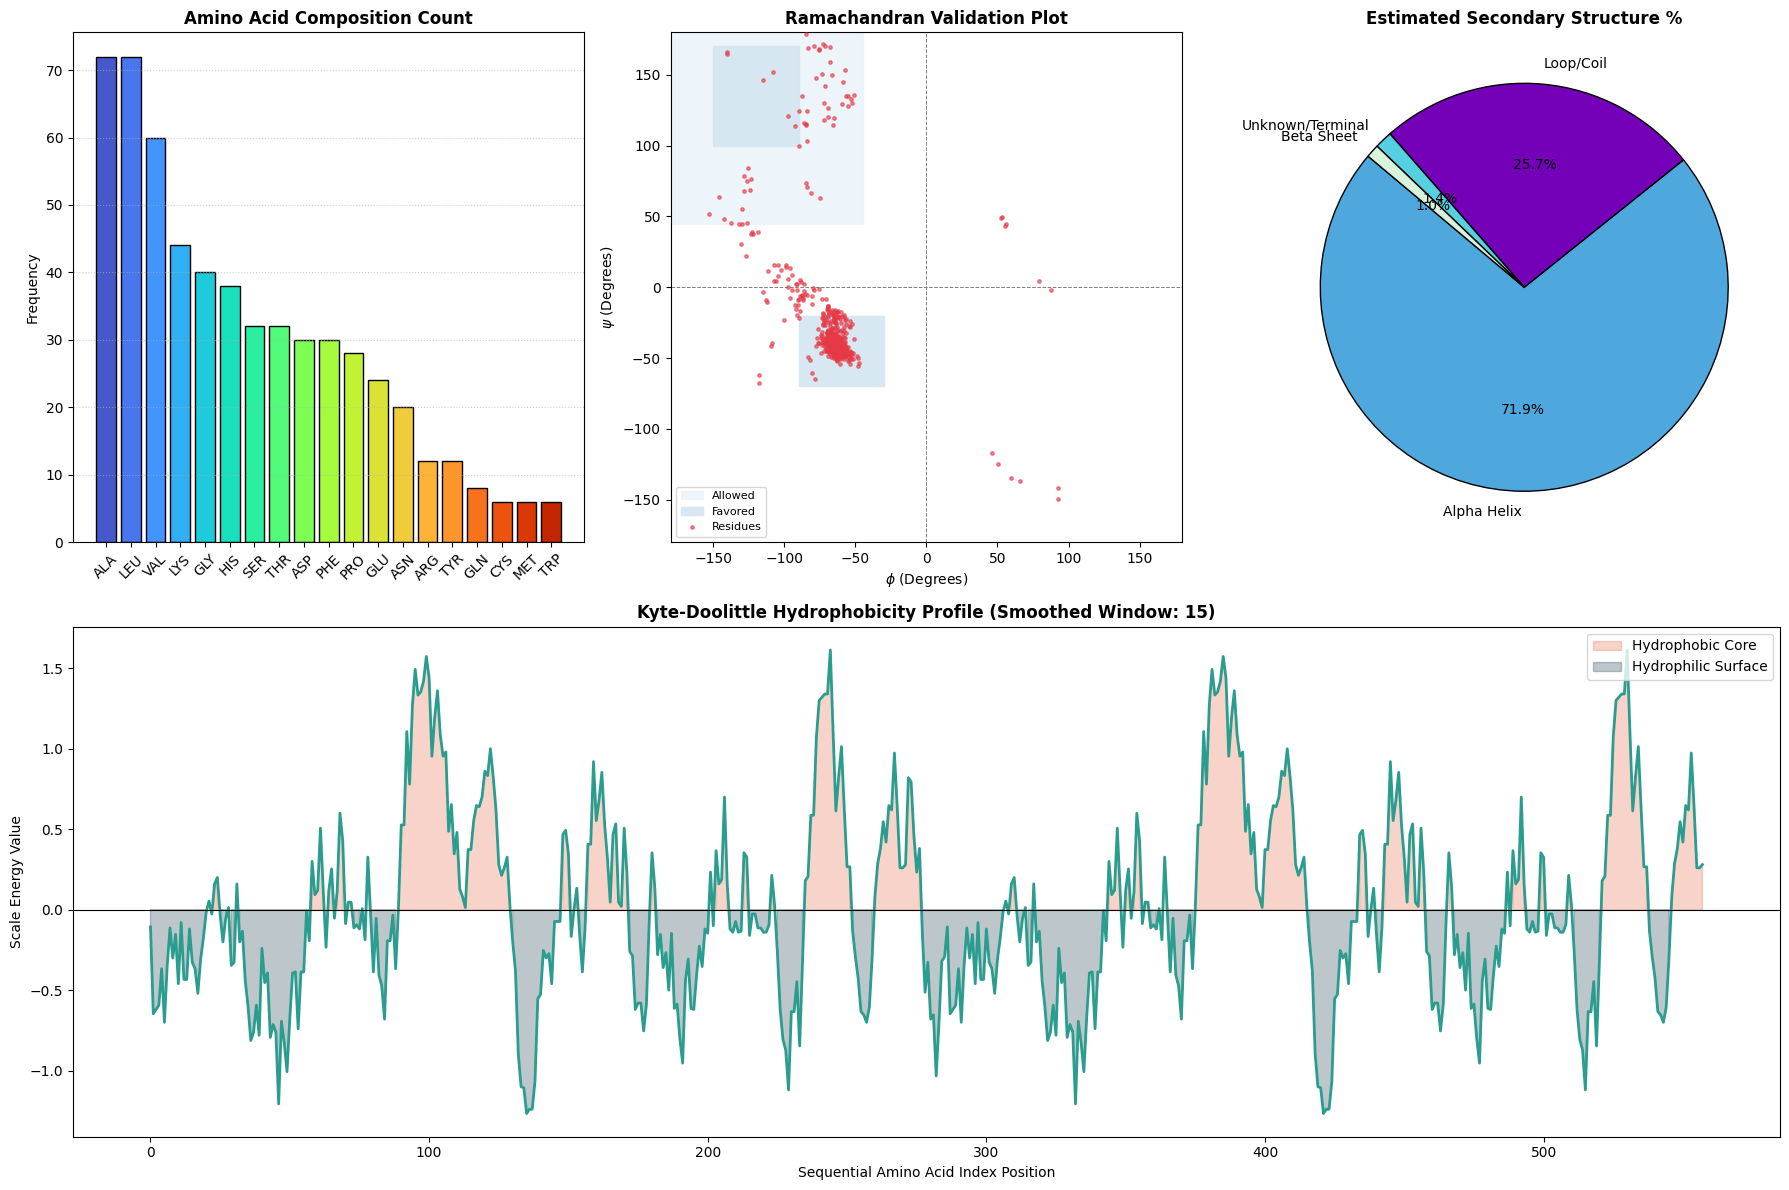

 Saved Dashboard panel image structure at: 1a3n_analysis_dashboard.png
 Saved structural metrics calculation table file at: 1a3n_structural_readings.csv

Displaying Interactive Structural Canvas view model inside workspace:
Execution process suspended. Factor info: Must instantiate viewer before generating image.


In [3]:
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
from Bio.PDB import PDBList, PDBParser, PPBuilder
from google.colab import files  # Triggers native browser automatic download downloads

# ==========================================
# 1. PARAMETERS & CONFIGURATION
# ==========================================
# Change this ID to analyze any protein structure you like (e.g., "1A3N", "6LU7", "1MBO")
PDB_ID = "1A3N"

# Kyte-Doolittle Hydrophobicity Index mapping values
HYDROPHOBICITY_SCALE = {
    "ALA": 1.8, "ARG": -4.5, "ASN": -3.5, "ASP": -3.5, "CYS": 2.5,
    "GLN": -3.5, "GLU": -3.5, "GLY": -0.4, "HIS": -3.2, "ILE": 4.5,
    "LEU": 3.8, "LYS": -3.9, "MET": 1.9, "PHE": 2.8, "PRO": -1.6,
    "SER": -0.8, "THR": -0.7, "TRP": -0.9, "TYR": -1.3, "VAL": 4.2
}

# ==========================================
# 2. DATA ACQUISITION PIPELINE
# ==========================================
def fetch_pdb_file(pdb_id):
    """Downloads structural coordinates map file directly from RCSB database server."""
    pdbl = PDBList()
    filename = pdbl.retrieve_pdb_file(pdb_id, pdir=".", file_format="pdb", overwrite=True)
    standard_name = f"{pdb_id.lower()}.pdb"
    if os.path.exists(filename):
        if os.path.exists(standard_name):
            os.remove(standard_name)
        os.rename(filename, standard_name)
        return standard_name
    raise FileNotFoundError(f"Structure verification failed for target ID: {pdb_id}")

# ==========================================
# 3. BIOPYTHON EXTRACTION & MATH MATRIX
# ==========================================
def extract_structural_readings(pdb_file_path):
    """Parses structural hierarchies and builds tabular residue profile arrays."""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file_path)

    aa_counts = {k: 0 for k in HYDROPHOBICITY_SCALE.keys()}
    tabular_records = []

    ppb = PPBuilder()
    residue_global_index = 1

    for model in structure:
        for chain in model:
            chain_id = chain.get_id()

            # Record individual counts
            for residue in chain:
                res_name = residue.get_resname().strip()
                if res_name in aa_counts:
                    aa_counts[res_name] += 1

            # Map structural backbone geometry angles
            for pp in ppb.build_peptides(chain):
                sequence = pp.get_sequence()
                phi_psi_list = pp.get_phi_psi_list()

                for i, (phi, psi) in enumerate(phi_psi_list):
                    res_obj = pp[i]
                    res_name = res_obj.get_resname().strip()

                    if res_name not in HYDROPHOBICITY_SCALE:
                        continue

                    phi_deg = phi * 180 / np.pi if phi is not None else None
                    psi_deg = psi * 180 / np.pi if psi is not None else None

                    # Geometry criteria secondary structural rough filter assignment
                    if phi_deg is not None and psi_deg is not None:
                        if -90 <= phi_deg <= -30 and -80 <= psi_deg <= -20:
                            sec_struct_label = "Alpha Helix"
                        elif -150 <= phi_deg <= -90 and 90 <= psi_deg <= 170:
                            sec_struct_label = "Beta Sheet"
                        else:
                            sec_struct_label = "Loop/Coil"
                    else:
                        sec_struct_label = "Unknown/Terminal"

                    tabular_records.append({
                        "Residue_Position": residue_global_index,
                        "Chain_ID": chain_id,
                        "Residue_Type": res_name,
                        "Phi_Angle": round(phi_deg, 3) if phi_deg else np.nan,
                        "Psi_Angle": round(psi_deg, 3) if psi_deg else np.nan,
                        "Hydrophobicity_Score": HYDROPHOBICITY_SCALE.get(res_name, 0.0),
                        "Assigned_Structure": sec_struct_label
                    })
                    residue_global_index += 1

    return aa_counts, pd.DataFrame(tabular_records)

# ==========================================
# 4. EXPORT VISUALIZATION GRAPH PANELS
# ==========================================
def save_and_render_plots(aa_counts, df_metrics, img_output_path):
    """Plots and builds structural figures, exporting them directly as high-res PNG."""
    fig = plt.figure(figsize=(18, 12))

    # Plot 1: Amino Acid Counts
    ax1 = plt.subplot(2, 3, 1)
    sorted_aa = sorted({k:v for k,v in aa_counts.items() if v > 0}.items(), key=lambda x: x[1], reverse=True)
    labels, counts = zip(*sorted_aa) if sorted_aa else ([], [])
    ax1.bar(labels, counts, color=cm.turbo(np.linspace(0.1, 0.9, len(labels))), edgecolor="black")
    ax1.set_title("Amino Acid Composition Count", fontsize=12, fontweight="bold")
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylabel("Frequency")
    ax1.grid(axis='y', linestyle=':', alpha=0.6)

    # Plot 2: Ramachandran Validation Map
    ax2 = plt.subplot(2, 3, 2)
    ax2.fill_between([-180, -45], 45, 180, color="#EBF4FA", alpha=0.9, label="Allowed")
    ax2.fill_between([-90, -30], -70, -20, color="#D4E6F1", alpha=0.9, label="Favored")
    ax2.fill_between([-150, -90], 100, 170, color="#D4E6F1", alpha=0.9)

    df_clean = df_metrics.dropna(subset=["Phi_Angle", "Psi_Angle"])
    ax2.scatter(df_clean["Phi_Angle"], df_clean["Psi_Angle"], color="#E63946", s=6, alpha=0.6, zorder=3, label="Residues")
    ax2.set_xlim(-180, 180)
    ax2.set_ylim(-180, 180)
    ax2.axhline(0, color="grey", linewidth=0.7, linestyle="--")
    ax2.axvline(0, color="grey", linewidth=0.7, linestyle="--")
    ax2.set_title("Ramachandran Validation Plot", fontsize=12, fontweight="bold")
    ax2.set_xlabel(r"$\phi$ (Degrees)")
    ax2.set_ylabel(r"$\psi$ (Degrees)")
    ax2.legend(loc="lower left", fontsize=8)

    # Plot 3: Structural Breakdown Distribution
    ax3 = plt.subplot(2, 3, 3)
    struct_counts = df_metrics["Assigned_Structure"].value_counts()
    ax3.pie(struct_counts, labels=struct_counts.index, autopct="%1.1f%%", startangle=140,
            colors=["#4EA8DE", "#7400B8", "#56CFE1", "#D8F3DC"], wedgeprops={"edgecolor": "black"})
    ax3.set_title("Estimated Secondary Structure %", fontsize=12, fontweight="bold")

    # Plot 4: Hydrophobicity Graph Profile Matrix
    ax4 = plt.subplot(2, 1, 2)
    hp_scores = df_metrics["Hydrophobicity_Score"].values
    window_size = min(15, max(3, len(hp_scores) // 20))
    if len(hp_scores) >= window_size:
        smoothed = np.convolve(hp_scores, np.ones(window_size)/window_size, mode='valid')
        ax4.plot(smoothed, color="#2A9D8F", linewidth=2)
        ax4.fill_between(range(len(smoothed)), smoothed, 0, where=(smoothed >= 0), color="#E76F51", alpha=0.3, label="Hydrophobic Core")
        ax4.fill_between(range(len(smoothed)), smoothed, 0, where=(smoothed < 0), color="#264653", alpha=0.3, label="Hydrophilic Surface")
    ax4.set_title(f"Kyte-Doolittle Hydrophobicity Profile (Smoothed Window: {window_size})", fontsize=12, fontweight="bold")
    ax4.set_xlabel("Sequential Amino Acid Index Position")
    ax4.set_ylabel("Scale Energy Value")
    ax4.axhline(0, color="black", linewidth=0.8)
    ax4.legend(loc="upper right")

    plt.tight_layout()
    plt.savefig(img_output_path, dpi=300)
    plt.show()
    print(f" Saved Dashboard panel image structure at: {img_output_path}")

# ==========================================
# 5. INTERACTIVE 3D COMPONENT CANVAS RENDER
# ==========================================
def display_3d_canvas(pdb_file_path):
    """Loads interactive WebGL model engine viewer inside the web workspace layout environment."""
    with open(pdb_file_path, 'r') as f:
        data = f.read()
    view = py3Dmol.view(width=800, height=500)
    view.addModel(data, "pdb")
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()
    view.png() # Prepares canvas frame data to extract safely
    return view.show()

# ==========================================
# 6. OPERATIONAL PIPELINE EXECUTION
# ==========================================
try:
    print(f"Starting analysis framework for target structural sequence model: PDB [{PDB_ID.upper()}]...")

    # Filenames for files to save
    csv_file = f"{PDB_ID.lower()}_structural_readings.csv"
    dashboard_img = f"{PDB_ID.lower()}_analysis_dashboard.png"

    # Run pipeline operations
    local_pdb = fetch_pdb_file(PDB_ID)
    counts_dict, df_result = extract_structural_readings(local_pdb)

    # 1. Generate and Export Dashboard Figure Image (.png)
    save_and_render_plots(counts_dict, df_result, dashboard_img)

    # 2. Save full data matrix calculations table sheet (.csv)
    df_result.to_csv(csv_file, index=False)
    print(f" Saved structural metrics calculation table file at: {csv_file}")

    # 3. Present Interactive 3D Structural Layout Frame Canvas
    print("\nDisplaying Interactive Structural Canvas view model inside workspace:")
    display_3d_canvas(local_pdb)

    # 4. Trigger Native Browser Automated Transfers Download UI
    print("\nTriggering local file package delivery downloads to your machine...")
    files.download(csv_file)       # Automatically downloads your data table spreadsheet
    files.download(dashboard_img)  # Automatically downloads your complete 4-panel dashboard graphic
    print("Download sequence completed. Check your local browser download history.")

except Exception as workflow_error:
    print(f"Execution process suspended. Factor info: {workflow_error}")